In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from linear_lottery import run_linear_lottery

In [2]:
# Load Swiss NSF Raw Scores
review_data = pd.read_csv("data/swiss_nsf_scores.csv")
review_agg = review_data.groupby("proposal").num_grade.agg(['mean', 'count']).reset_index()

u = review_agg['mean'].to_numpy()
min_count = review_agg['count'].min()
delta_u = 1. / min_count # largest possible change in utility due to change in one review
score_range = u.min(), u.max()

In [3]:
score_range

(1.0, 6.0)

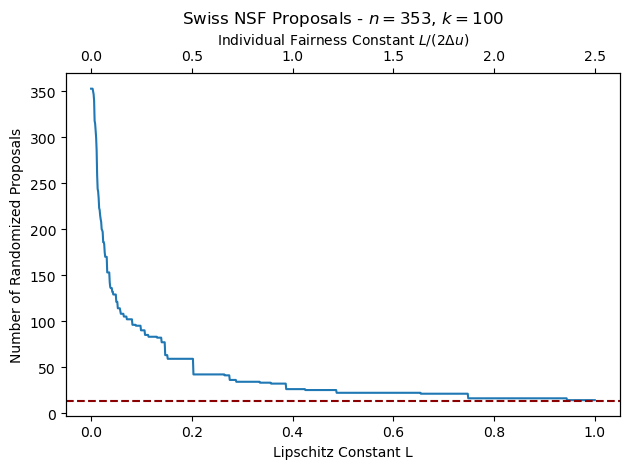

In [18]:
k = 100

CURRENT = 13 # current number of randomized proposals under existing Swiss NSF method

Ls = np.linspace(0.0, 1., 1000)
R = []
for L in Ls:
    L_lottery = L / (2*delta_u)
    p = run_linear_lottery(u, L_lottery, k=10)
    # get number randomized 
    num_randomized = np.sum((p > 1e-6) & (p < 1 - 1e-6))
    R.append(num_randomized)

fig, ax1 = plt.subplots()
ax1.plot(Ls, R)
ax1.axhline(CURRENT, color='darkred', linestyle='--', label='Current Swiss NSF Method')
ax1.set_xlabel("Lipschitz Constant L")
ax1.set_ylabel("Number of Randomized Proposals")

# Create twin axis with proper limits
ax2 = ax1.twiny()
ax2.set_xlabel("Individual Fairness Constant $L / (2 \\Delta u)$")
ax2.set_xlim(ax1.get_xlim()[0] / (2*delta_u), ax1.get_xlim()[1] / (2*delta_u))

plt.title("Swiss NSF Proposals - $n = {}$, $k = {}$".format(len(u), k))
plt.tight_layout()
plt.show()

In [ ]:
# get number of randomized proposals with k = k-th highest utility (LB for utility)
sum(u == sorted(u, reverse=True)[k])

6